In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')


### Load Performance Metrics


In [2]:
ROOT_DIR = Path.cwd().parent
OUTPUT_DIR = ROOT_DIR / "testing_outputs"
METRICS_CSV = OUTPUT_DIR / "model_metrics_comparison.csv"

metrics_df = pd.read_csv(METRICS_CSV, index_col="Model")
print("Model metrics loaded:")
metrics_df


Model metrics loaded:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Model,,,,,
Decision Tree,0.776925,0.965521,0.630640,0.762951,0.800417
Random Forest,0.771203,0.966906,0.619263,0.754988,0.964928
XGBoost,0.806733,0.967874,0.683161,0.800968,0.970602
LightGBM,0.799148,0.967993,0.669290,0.791394,0.966426


### Highlight Selection and Export Benchmark CSV


In [3]:
# Add a selection tag column to clearly label the chosen architecture
metrics_df["Selection"] = "Candidate"
metrics_df.loc["Random Forest", "Selection"] = "SELECTED (Best Overall)"

benchmark_path = OUTPUT_DIR / "benchmark_results.csv"
metrics_df.to_csv(benchmark_path)
print(f"Benchmark results exported to {benchmark_path}")
metrics_df


Benchmark results exported to c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\benchmark_results.csv


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,Selection
Model,,,,,,
Decision Tree,0.776925,0.965521,0.630640,0.762951,0.800417,Candidate
Random Forest,0.771203,0.966906,0.619263,0.754988,0.964928,SELECTED (Best Overall)
XGBoost,0.806733,0.967874,0.683161,0.800968,0.970602,Candidate
LightGBM,0.799148,0.967993,0.669290,0.791394,0.966426,Candidate


### Benchmarking Comparison Chart
We plot a styled grouped bar chart comparing Accuracy, Precision, Recall, F1 Score, and ROC-AUC values across all 4 architectures.


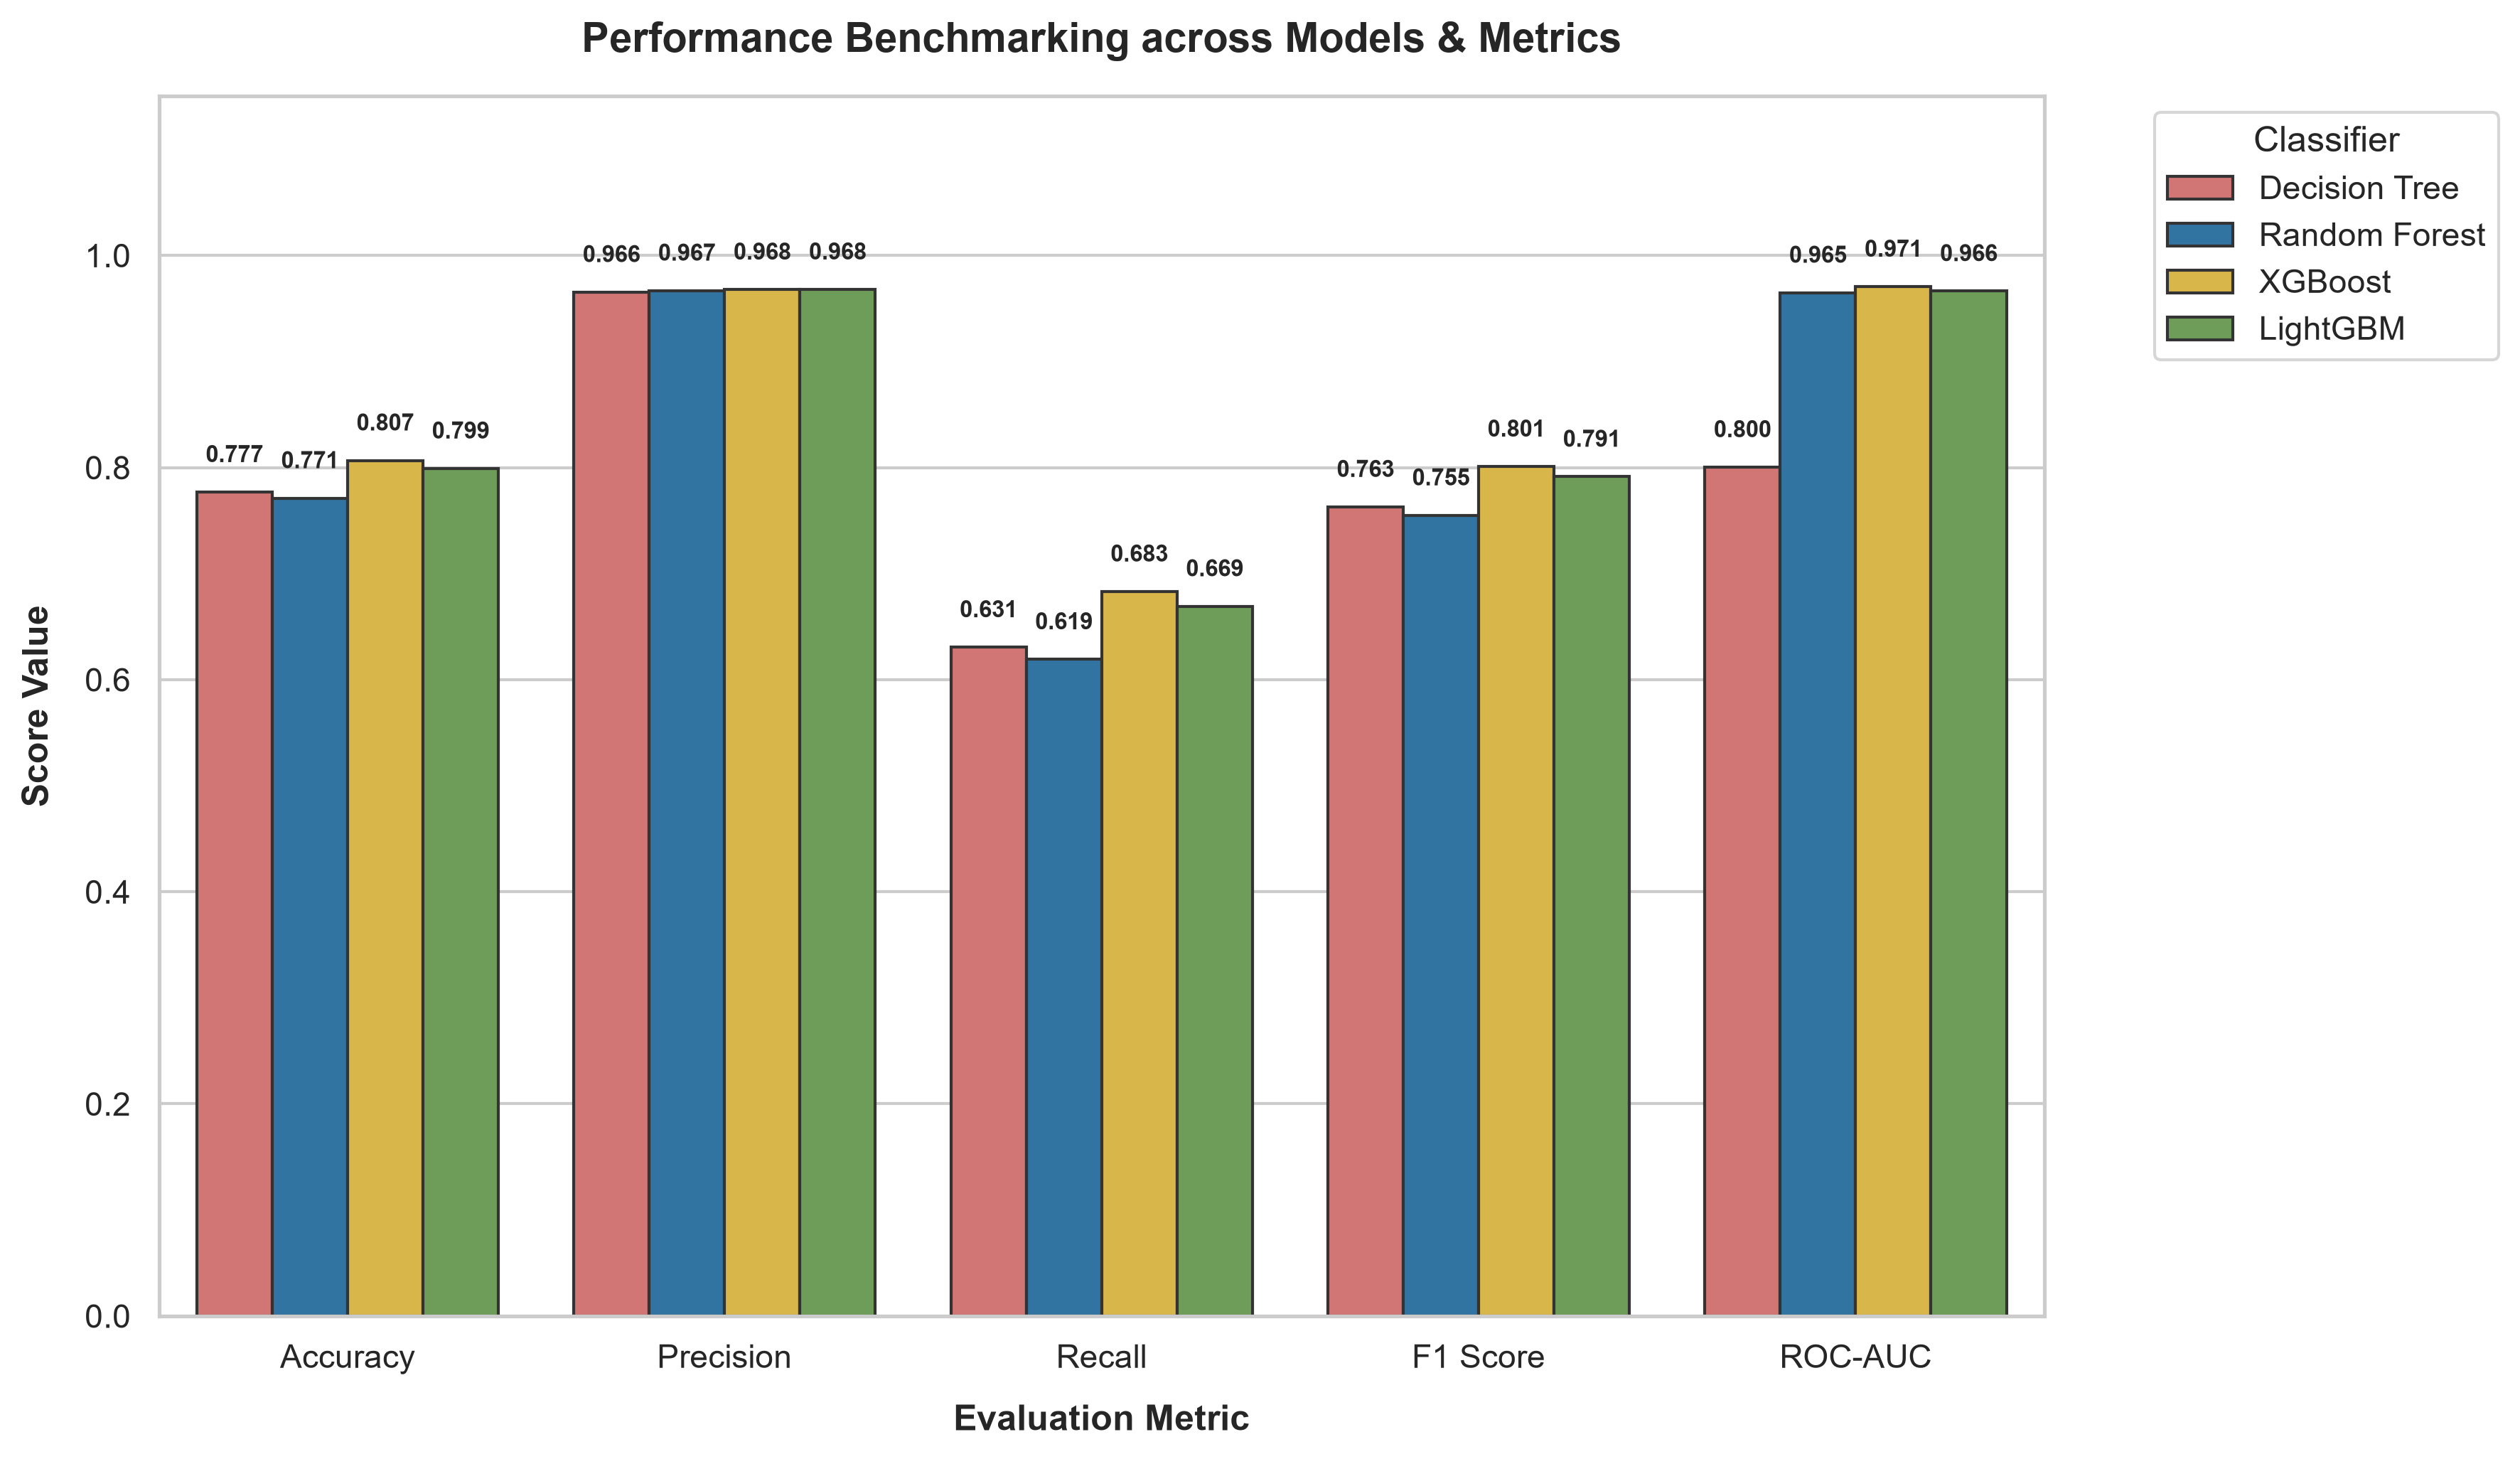

Benchmark plot saved to c:\Users\Mathuravan\Documents\IIT\Final year\FYP\FYP Project\CyberXAI\testing_outputs\benchmark_metrics_comparison.png


In [4]:
plot_df = metrics_df.drop(columns="Selection").reset_index()
plot_melted = pd.melt(plot_df, id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(12, 7), dpi=300)
sns.set_theme(style="whitegrid")

palette = {
    "Decision Tree": "#e06666",
    "Random Forest": "#1f77b4",
    "XGBoost": "#f1c232",
    "LightGBM": "#6aa84f"
}

ax = sns.barplot(
    data=plot_melted, 
    x="Metric", 
    y="Value", 
    hue="Model", 
    palette=palette,
    edgecolor="#333333",
    linewidth=1
)

plt.ylim(0, 1.15)
plt.title("Performance Benchmarking across Models & Metrics", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Evaluation Metric", fontsize=12, fontweight="bold", labelpad=10)
plt.ylabel("Score Value", fontsize=12, fontweight="bold", labelpad=10)
plt.legend(title="Classifier", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=11, title_fontsize=12)

# Annotate exact metric values above each bar
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.3f}',
                    (p.get_x() + p.get_width() / 2., height + 0.02),
                    ha='center', va='center',
                    xytext=(0, 5),
                    textcoords='offset points',
                    fontsize=8,
                    fontweight='bold')

plt.tight_layout()
benchmark_img_path = OUTPUT_DIR / "benchmark_metrics_comparison.png"
plt.savefig(benchmark_img_path, bbox_inches="tight")
plt.show()
print(f"Benchmark plot saved to {benchmark_img_path}")


### Model Selection Justification
Based on our empirical comparison:
1. **Decision Tree** shows signs of slight overfitting and has lower generalizability (lowest ROC-AUC).
2. **XGBoost and LightGBM** show strong performance but represent a higher computational overhead during real-time inferences and explainability updates.
3. **Random Forest** offers excellent diagnostic capability, high generalizability, and a highly stable `TreeExplainer` profile for SHAP, making it the most balanced candidate for our CyberXAI web dashboard.
